In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import copy

from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

from models.LSTMAE import LSTMAE


In [2]:
file_path = "SPEI_AllScales_Napak - SPEI_AllScales_Napak.csv"


In [3]:
df = pd.read_csv(file_path)

series = df.iloc[:,4].values.reshape(-1,1)
series.shape

(539, 1)

In [4]:
scaler = MinMaxScaler(feature_range = (-1,1))
series_scaled = scaler.fit_transform(series)

series_scaled.shape

(539, 1)

In [5]:
def series_to_Xy(arr, window_size):
    X = []
    y = []

    for i in range(len(arr)-window_size):
        X.append(arr[i:i+ window_size])
        y.append(arr[i + window_size])

    return np.array(X), np.array(y)

In [6]:
ws = 20

X_all_train, y_all_train = series_to_Xy(series_scaled, ws)

X_train = X_all_train[:400]
X_val = X_all_train[400:]

y_train = y_all_train[:400]
y_val = y_all_train[400:]

X_train_torch = torch.tensor(X_train, dtype=torch.float32)
X_val_torch = torch.tensor(X_val, dtype=torch.float32)

batch_size = 64

train_dataset = TensorDataset(X_train_torch, X_train_torch)
val_dataset = TensorDataset(X_val_torch, X_val_torch)
train_loader = DataLoader(
    train_dataset,
    batch_size = batch_size,
    shuffle = True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)


In [7]:
device = torch.device("cpu")

input_size = 1
hidden_size = 6
dropout_ratio = 0.0
seq_len = ws

model = LSTMAE(
    input_size=input_size,
    hidden_size=hidden_size,
    dropout_ratio=dropout_ratio,
    seq_len=seq_len,
    use_act=False
)

model = model.to(device)

print(model)

LSTMAE(
  (encoder): Encoder(
    (lstm_enc): LSTM(1, 6, batch_first=True)
  )
  (decoder): Decoder(
    (act): Tanh()
    (lstm_dec): LSTM(6, 6, batch_first=True)
    (fc): Linear(in_features=6, out_features=1, bias=True)
  )
)


In [8]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.05)

In [9]:
n_epochs = 500

train_loss = []
val_loss = []

best_val_loss = float("inf")
best_model_state = None

for epoch in range(n_epochs):
    model.train()
    total_train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        X_recontruct = model(X_batch)

        loss = criterion(X_recontruct, y_batch)
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item() * X_batch.size(0)
    avg_train_loss = total_train_loss/len(train_loader.dataset)
    
    model.eval()
    total_val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            X_reconstruct = model(X_batch)

            loss = criterion(X_reconstruct, y_batch)

            total_val_loss += loss.item() * X_batch.size(0)
        
        avg_val_loss = total_train_loss/len(val_loader.dataset)

        train_loss.append(avg_train_loss)
        val_loss.append(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = copy.deepcopy(model.state_dict())

        if (epoch + 1) % 10 == 0:
            print(
                f"Epoch [{epoch + 1}/{n_epochs}] "
                f"Train Loss: {avg_train_loss:.6f} "
                f"Val Loss: {avg_val_loss:.6f}"
        )

model.load_state_dict(best_model_state)

print("Best validation loss:", best_val_loss)

    

Epoch [10/500] Train Loss: 0.175460 Val Loss: 0.589783
Epoch [20/500] Train Loss: 0.170444 Val Loss: 0.572922
Epoch [30/500] Train Loss: 0.149854 Val Loss: 0.503712
Epoch [40/500] Train Loss: 0.076288 Val Loss: 0.256431
Epoch [50/500] Train Loss: 0.069505 Val Loss: 0.233632
Epoch [60/500] Train Loss: 0.067191 Val Loss: 0.225853
Epoch [70/500] Train Loss: 0.067588 Val Loss: 0.227188
Epoch [80/500] Train Loss: 0.060013 Val Loss: 0.201723
Epoch [90/500] Train Loss: 0.059860 Val Loss: 0.201210
Epoch [100/500] Train Loss: 0.059972 Val Loss: 0.201587
Epoch [110/500] Train Loss: 0.059088 Val Loss: 0.198616
Epoch [120/500] Train Loss: 0.058489 Val Loss: 0.196603
Epoch [130/500] Train Loss: 0.054080 Val Loss: 0.181782
Epoch [140/500] Train Loss: 0.055598 Val Loss: 0.186882
Epoch [150/500] Train Loss: 0.053925 Val Loss: 0.181262
Epoch [160/500] Train Loss: 0.051595 Val Loss: 0.173427
Epoch [170/500] Train Loss: 0.058442 Val Loss: 0.196443
Epoch [180/500] Train Loss: 0.051332 Val Loss: 0.172544
E

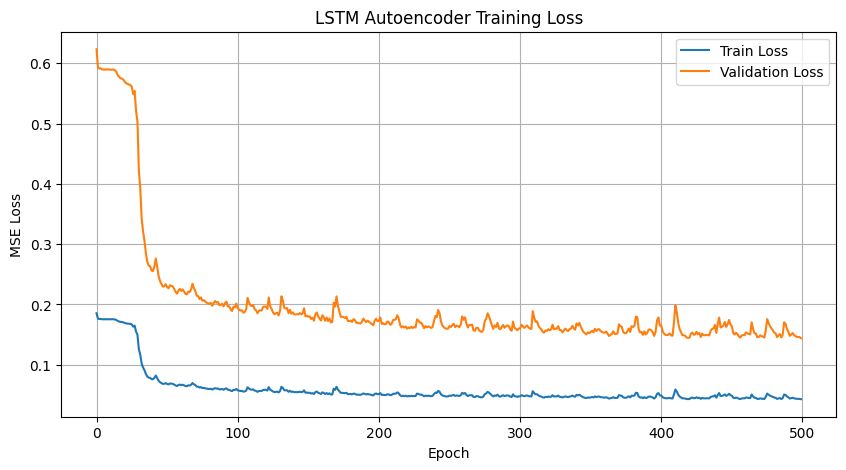

In [11]:


plt.figure(figsize=(10, 5))
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Autoencoder Training Loss")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
# =========================
# GET TRAIN RECONSTRUCTIONS
# =========================

model.eval()

with torch.no_grad():
    X_train_reconstructed = model(X_train_torch.to(device)).cpu().numpy()

print("X_train shape:", X_train.shape)
print("X_train_reconstructed shape:", X_train_reconstructed.shape)

X_train shape: (400, 20, 1)
X_train_reconstructed shape: (400, 20, 1)


In [13]:
# =========================
# RECONSTRUCT CONTINUOUS SERIES FROM OVERLAPPING WINDOWS
# =========================

def reconstruct_series_from_windows(windows):
    """
    Convert overlapping windows back into one continuous series
    by averaging overlapping reconstructed values.

    Input:
        windows shape = (num_windows, window_size, 1)

    Output:
        series shape = (num_windows + window_size, 1)
    """

    num_windows = windows.shape[0]
    window_size = windows.shape[1]

    reconstructed = np.zeros(num_windows + window_size)
    counts = np.zeros(num_windows + window_size)

    for i in range(num_windows):
        reconstructed[i:i + window_size] += windows[i, :, 0]
        counts[i:i + window_size] += 1

    reconstructed = reconstructed / counts

    return reconstructed.reshape(-1, 1)

/var/folders/lb/7b4tdngx1x1g1zn730j5fv900000gq/T/ipykernel_939/1245524517.py:27: RuntimeWarning: invalid value encountered in divide
  reconstructed = reconstructed / counts


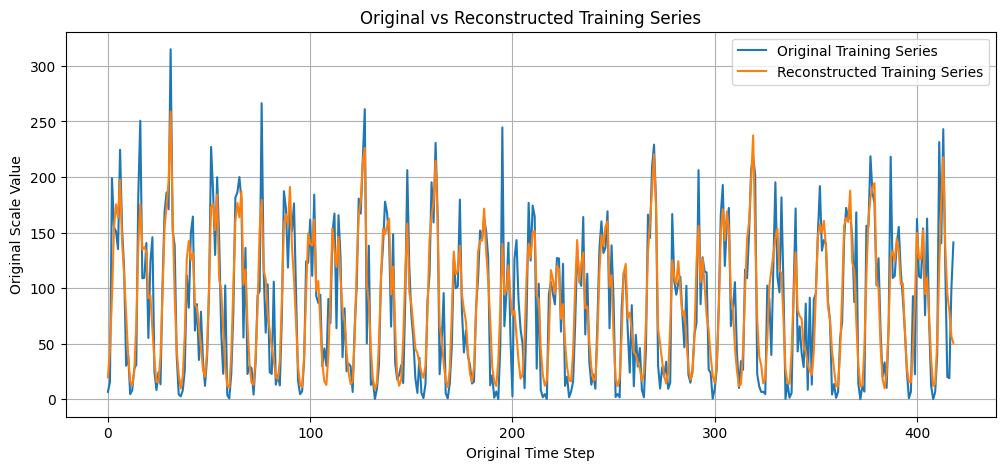

In [14]:
# =========================
# ORIGINAL TRAIN SERIES VS RECONSTRUCTED TRAIN SERIES
# =========================

train_original_scaled_series = reconstruct_series_from_windows(X_train)
train_reconstructed_scaled_series = reconstruct_series_from_windows(X_train_reconstructed)

train_original_series = scaler.inverse_transform(train_original_scaled_series)
train_reconstructed_series = scaler.inverse_transform(train_reconstructed_scaled_series)

plt.figure(figsize=(12, 5))
plt.plot(train_original_series, label="Original Training Series")
plt.plot(train_reconstructed_series, label="Reconstructed Training Series")
plt.xlabel("Original Time Step")
plt.ylabel("Original Scale Value")
plt.title("Original vs Reconstructed Training Series")
plt.legend()
plt.grid(True)
plt.show()